# Double-Blind: A Mutual Privacy Perserving Image Crop Verification Protocol #

This jupyter notebook provide experiment result(s) to the proposed protocol. It generates graphs and compare our protocol with other baselines

In [1]:
import time
import csv
# Import the high-level protocol wrappers
from image import CryptoImage
from bsp import get_random_ppm
from protocol import Setup, ProtocolServer, ProtocolClient
import random
import time
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image as PILImage

In [2]:
# ==========================================
# VISUALIZATION HELPER
# ==========================================
def get_grid_dimensions(width, height, block_num):
    """Replicates the grid math from CryptoImage to render the visual lines."""
    best_c, best_r = block_num, 1
    target_ratio = width / height
    best_diff = float('inf')

    for r in range(1, int(math.sqrt(block_num)) + 1):
        if block_num % r == 0:
            c = block_num // r
            if abs((c / r) - target_ratio) < best_diff:
                best_diff = abs((c / r) - target_ratio)
                best_c, best_r = c, r
            if abs((r / c) - target_ratio) < best_diff:
                best_diff = abs((r / c) - target_ratio)
                best_c, best_r = r, c
                
    return best_c, best_r

def visualize_crop(image_path, total_blocks, subset_indices):
    """Renders the original image grid and the extracted crop using matplotlib."""
    print("[*] Generating visual grid...")
    img = PILImage.open(image_path).convert('RGB')
    width, height = img.size
    cols, rows = get_grid_dimensions(width, height, total_blocks)
    
    block_w = width // cols
    block_h = height // rows

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.canvas.manager.set_window_title('Double-Blind Protocol Visualization')

    # --- Plot 1: Original Image with Grid ---
    ax1.imshow(img)
    ax1.set_title(f"Original Dataset ({cols}x{rows} Grid, {total_blocks} Blocks)")
    ax1.axis('off')
    
    for r in range(rows):
        for c in range(cols):
            left = c * block_w
            upper = r * block_h
            right = width if c == cols - 1 else (c + 1) * block_w
            lower = height if r == rows - 1 else (r + 1) * block_h
            
            # Draw grid lines
            rect = patches.Rectangle((left, upper), right-left, lower-upper,
                                     linewidth=1, edgecolor='white', facecolor='none', alpha=0.5)
            ax1.add_patch(rect)
            
            # Draw index numbers
            idx = r * cols + c
            ax1.text(left + (right-left)/2, upper + (lower-upper)/2, str(idx),
                     color='white', ha='center', va='center', fontsize=8,
                     bbox=dict(facecolor='black', alpha=0.6, pad=1, edgecolor='none'))

    # --- Plot 2: The Cropped Subset (Juxtaposed) ---
    ax2.set_title(f"Client's Cropped Subset\n Picked Indices: {subset_indices}")
    ax2.axis('off')

    # Calculate a mini-grid to display the extracted blocks side-by-side
    k = len(subset_indices)
    gallery_cols = math.ceil(math.sqrt(k))
    gallery_rows = math.ceil(k / gallery_cols)
    
    # Create a blank black canvas for the juxtaposed blocks
    gallery_img = PILImage.new('RGB', (gallery_cols * block_w, gallery_rows * block_h), (0, 0, 0))

    for i, idx in enumerate(subset_indices):
        # 1. Find the block's original coordinates
        r = idx // cols
        c = idx % cols
        left = c * block_w
        upper = r * block_h
        right = width if c == cols - 1 else (c + 1) * block_w
        lower = height if r == rows - 1 else (r + 1) * block_h

        # 2. Extract the block
        box = (left, upper, right, lower)
        block_img = img.crop(box)
        
        # 3. Calculate its new position in the mini-grid
        g_row = i // gallery_cols
        g_col = i % gallery_cols
        g_left = g_col * block_w
        g_upper = g_row * block_h
        
        # 4. Paste the block into the new canvas
        gallery_img.paste(block_img, (g_left, g_upper))
        
        # 5. Draw a red border around the block on the new canvas
        rect = patches.Rectangle((g_left, g_upper), right-left, lower-upper,
                                 linewidth=2, edgecolor='red', facecolor='none', zorder=4)
        ax2.add_patch(rect)
        
        # 6. Add the original index number so we know which piece is which
        ax2.text(g_left + (right-left)/2, g_upper + (lower-upper)/2, str(idx),
                 color='white', ha='center', va='center', fontsize=12, fontweight='bold',
                 bbox=dict(facecolor='black', alpha=0.6, pad=2, edgecolor='none'), zorder=5)

    # Finally, show the stitched collage image on the right axis
    ax2.imshow(gallery_img, zorder=1)

    plt.tight_layout()
    # Draw the plot non-blocking so the console protocol can continue running
    plt.show(block=False)
    plt.pause(0.1)

# 1. Protocol Setup and Toy Example # 

  DOUBLE-BLIND PROTOCOL: VISUAL TOY EXECUTION

[*] Locating random COCO image in 'image_dataset'...
[+] Selected: image_dataset\000000065350.ppm

[*] Generating visual grid...


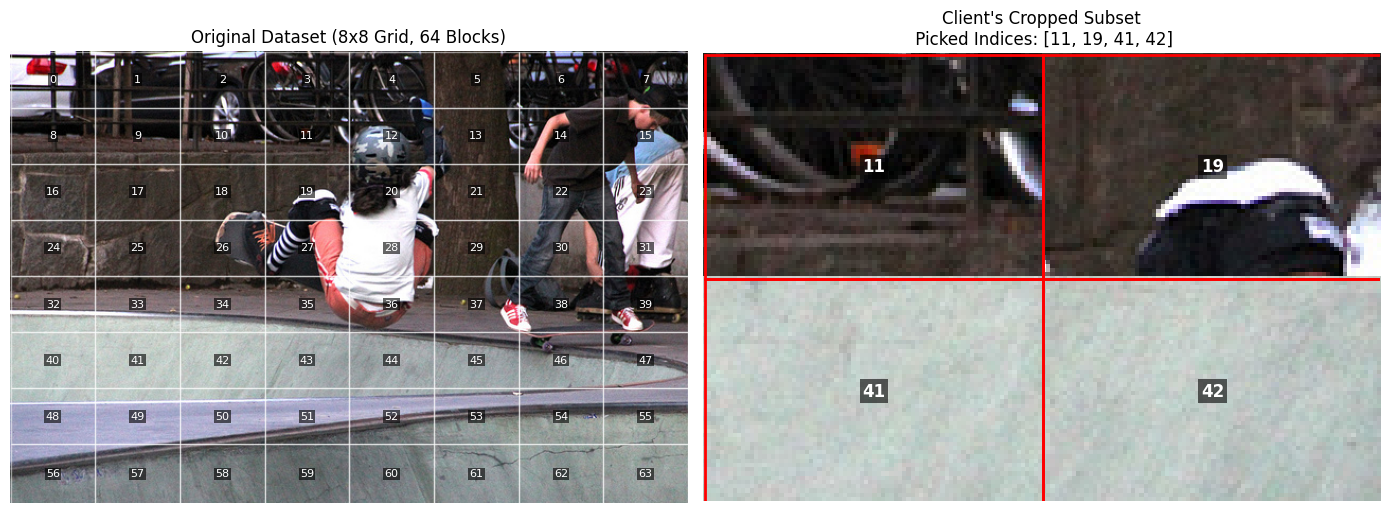

[*] Initializing Global Parameters (N = 64)...
[+] Setup Complete. (0.63s)

--- PHASE 1: OFFLINE REGISTRATION ---
[*] Parsing and partitioning image into 64 blocks...
[*] Server generating OPRF tags and Keyed KZG commitment...
[+] Registration Complete. (1.54s)
    Ledger Anchor (C_sk) securely generated.

--- PHASE 2: HONEST SUBSET VERIFICATION ---
[*] Client attempting to verify subset of size 4
    Padding batch to size: 8 to prevent side-channel leaks...
[+] SUCCESS: Honest execution accepted! Output: 1 (6.02s)



In [3]:
# ==========================================
# MAIN EXECUTION
# ==========================================
def run_visual_protocol():
    print("==================================================")
    print("  DOUBLE-BLIND PROTOCOL: VISUAL TOY EXECUTION")
    print("==================================================\n")

    # --- Configuration Parameters ---
    TOTAL_BLOCKS = 64              # Number of blocks to partition the image into
    PAD_TO_SIZE = 8               # Padding parameter (N_pad)
    DATASET_DIR = "image_dataset"  # Your COCO dataset directory

    # We will dynamically select a few random blocks to crop based on the grid
    import random

    try:
        print(f"[*] Locating random COCO image in '{DATASET_DIR}'...")
        test_image_path = get_random_ppm(DATASET_DIR)
        print(f"[+] Selected: {test_image_path}\n")
    except FileNotFoundError as e:
        print(f"[-] ERROR: {e}")
        return

    # Randomly select a subset to crop (e.g., 4 random blocks)
    SUBSET_INDICES = sorted(random.sample(range(TOTAL_BLOCKS), 4))
    
    # Render the matplotlib visualization
    visualize_crop(test_image_path, TOTAL_BLOCKS, SUBSET_INDICES)

    # ---------------------------------------------------------
    # 1. GLOBAL SETUP
    # ---------------------------------------------------------
    print(f"[*] Initializing Global Parameters (N = {TOTAL_BLOCKS})...")
    start_time = time.time()
    pp = Setup(max_image_blocks=TOTAL_BLOCKS)
    server = ProtocolServer(pp)
    client = ProtocolClient(pp, pk=server.pk)
    print(f"[+] Setup Complete. ({time.time() - start_time:.2f}s)\n")

    # ---------------------------------------------------------
    # PHASE 1: REGISTRATION (OFFLINE)
    # ---------------------------------------------------------
    print("--- PHASE 1: OFFLINE REGISTRATION ---")
    print(f"[*] Parsing and partitioning image into {TOTAL_BLOCKS} blocks...")
    full_image = CryptoImage(image_path=test_image_path, block_num=TOTAL_BLOCKS)

    print(f"[*] Server generating OPRF tags and Keyed KZG commitment...")
    reg_start = time.time()
    C_sk = server.Register(full_image)
    print(f"[+] Registration Complete. ({time.time() - reg_start:.2f}s)")
    print(f"    Ledger Anchor (C_sk) securely generated.\n")

    # ---------------------------------------------------------
    # PHASE 2: HONEST VERIFICATION (ONLINE)
    # ---------------------------------------------------------
    print("--- PHASE 2: HONEST SUBSET VERIFICATION ---")
    subset_image = full_image.crop(SUBSET_INDICES)
    
    print(f"[*] Client attempting to verify subset of size {len(SUBSET_INDICES)}")
    print(f"    Padding batch to size: {PAD_TO_SIZE} to prevent side-channel leaks...")

    verify_start = time.time()
    result_honest = client.Verify(
        subset=subset_image,
        C_sk=C_sk,
        server=server,
        total_image_blocks=TOTAL_BLOCKS,
        pad_to_size=PAD_TO_SIZE
    )
    verify_time = time.time() - verify_start

    if result_honest == 1:
        print(f"[+] SUCCESS: Honest execution accepted! Output: 1 ({verify_time:.2f}s)\n")
    else:
        print(f"[-] ERROR: Honest execution failed! Output: 0\n")
    # Keep the image window open until the user manually closes it
    plt.show(block=True)


run_visual_protocol()

# 2. Experiment on Various Parameters (Param Sweep) # 

- Define the testing parameters

In [3]:
N_VALUES = [16, 32, 64, 128, 256, 512, 1024]           # 1. Image block partition (Total Dataset Size)
I_VALUES = [4, 8, 16, 32, 64, 128, 256]               # 2. Subset block size (True requested crop)
PAD_VALUES = [8, 16, 32, 64, 128]           # 3. Dummy query padding (Side-channel protection)

ITERATIONS = 15                       # Runs per configuration to smooth out CPU noise
DATASET_DIR = "image_dataset"        # Folder containing the COCO .ppm files
BYTES_PER_G1_POINT = 96              # Bandwidth constant

In [4]:
def run_benchmarks():
    print("==================================================")
    print("  DOUBLE-BLIND PROTOCOL: AUTOMATED BENCHMARKING")
    print("==================================================\n")

    try:
        test_image_path = get_random_ppm(DATASET_DIR)
        print(f"[*] Base Image Selected: {test_image_path}\n")
    except FileNotFoundError as e:
        print(f"[-] ERROR: {e}")
        return

    csv_filename = "formal_benchmark_results.csv"
    with open(csv_filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([
            "Total_Blocks_N", 
            "Subset_Size_I", 
            "Padding_Size_Npad",
            "Avg_Offline_Reg_Time_s", 
            "Avg_Online_Verify_Time_s",
            "Total_Bandwidth_KB"
        ])

        for N in N_VALUES:
            print(f"--- 1. Testing Image Block Partition: N = {N} ---")
            
            # Setup Global Parameters
            pp = Setup(max_image_blocks=N)
            server = ProtocolServer(pp)
            client = ProtocolClient(pp, pk=server.pk)
            
            # Load and Partition the Real Image
            full_image = CryptoImage(image_path=test_image_path, block_num=N)
            
            # Measure Offline Registration (Server)
            total_reg_time = 0
            for _ in range(ITERATIONS):
                start = time.time()
                C_sk = server.Register(full_image)
                total_reg_time += (time.time() - start)
            avg_reg_time = total_reg_time / ITERATIONS
            print(f"[*] Avg Offline Registration Time: {avg_reg_time:.4f} s")

            # Measure Online Verification (Client + Server)
            for I in I_VALUES:
                if I > N: continue 
                
                for N_pad in PAD_VALUES:
                    # Constraints: Padding must cover I, and cannot exceed total N
                    if N_pad < I or N_pad > N: 
                        continue

                    print(f"    -> Sweeping Subset |I| = {I}, Padding N_pad = {N_pad}... ", end="", flush=True)

                    total_verify_time = 0
                    success_count = 0

                    for _ in range(ITERATIONS):
                        # Extract a random valid crop
                        subset_indices = sorted(random.sample(range(N), I))
                        subset_image = full_image.crop(subset_indices)

                        # Execute interactive protocol
                        start = time.time()
                        result = client.Verify(
                            subset=subset_image, 
                            C_sk=C_sk, 
                            server=server, 
                            total_image_blocks=N, 
                            pad_to_size=N_pad
                        )
                        total_verify_time += (time.time() - start)
                        
                        if result == 1:
                            success_count += 1

                    avg_verify_time = total_verify_time / ITERATIONS
                    
                    # Calculate Theoretical Bandwidth
                    client_tx_bytes = N_pad * BYTES_PER_G1_POINT
                    server_tx_bytes = (N_pad * BYTES_PER_G1_POINT) + (N_pad * BYTES_PER_G1_POINT)
                    total_kb = (client_tx_bytes + server_tx_bytes) / 1024.0

                    print(f"Done. (Avg Verify: {avg_verify_time:.4f} s, BW: {total_kb:.2f} KB)")
                    
                    if success_count != ITERATIONS:
                        print("       [!] WARNING: Protocol rejected an honest execution.")

                    # Log data row
                    writer.writerow([
                        N, I, N_pad, 
                        f"{avg_reg_time:.4f}", 
                        f"{avg_verify_time:.4f}", 
                        f"{total_kb:.2f}"
                    ])

    print(f"\n[+] Formal benchmarking complete. Results saved to '{csv_filename}'.")

In [ ]:
run_benchmarks()

  DOUBLE-BLIND PROTOCOL: AUTOMATED BENCHMARKING

[*] Base Image Selected: image_dataset\000000037988.ppm

--- 1. Testing Image Block Partition: N = 16 ---
[*] Avg Offline Registration Time: 0.4102 s
    -> Sweeping Subset |I| = 4, Padding N_pad = 8... Done. (Avg Verify: 5.7109 s, BW: 2.25 KB)
    -> Sweeping Subset |I| = 4, Padding N_pad = 16... Done. (Avg Verify: 9.3704 s, BW: 4.50 KB)
    -> Sweeping Subset |I| = 8, Padding N_pad = 8... Done. (Avg Verify: 6.3912 s, BW: 2.25 KB)
    -> Sweeping Subset |I| = 8, Padding N_pad = 16... Done. (Avg Verify: 10.0100 s, BW: 4.50 KB)
    -> Sweeping Subset |I| = 16, Padding N_pad = 16... Done. (Avg Verify: 10.2137 s, BW: 4.50 KB)
--- 1. Testing Image Block Partition: N = 32 ---
[*] Avg Offline Registration Time: 1.8466 s
    -> Sweeping Subset |I| = 4, Padding N_pad = 8... Done. (Avg Verify: 9.1835 s, BW: 2.25 KB)
    -> Sweeping Subset |I| = 4, Padding N_pad = 16... Done. (Avg Verify: 14.8772 s, BW: 4.50 KB)
    -> Sweeping Subset |I| = 4, Pad